# **Linear regression and Classificatio**

In [ ]:
'''Importing the Important Libraries '''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [48]:
'''Data Loading '''
df = pd.read_csv("bodyfat.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (252, 15)


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [49]:
''' data Info and cleanning '''
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nStatistical Summary:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB
None

Missing values:
 Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forea

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


In [50]:

# 1. Remove unrealistic values
df = df[df['Height'] > 50]          # Remove the wrong height (29.5 inches)
df = df[df['BodyFat'] > 0]          # Remove 0% body fat
df = df[df['BodyFat'] < 50]         # Remove extreme outliers

# 2. Convert units to metric (recommended)
df['Weight_kg'] = df['Weight'] * 0.453592
df['Height_cm'] = df['Height'] * 2.54
df['Height_m']  = df['Height_cm'] / 100

# 3. Create BMI
df['BMI'] = df['Weight_kg'] / (df['Height_m'] ** 2)

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (250, 19)


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Weight_kg,Height_cm,Height_m,BMI
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,69.966566,172.085,1.72085,23.626779
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,78.584814,183.515,1.83515,23.334338
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,69.853168,168.275,1.68275,24.668737
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2,83.801122,183.515,1.83515,24.883227
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7,83.574326,180.975,1.80975,25.517358


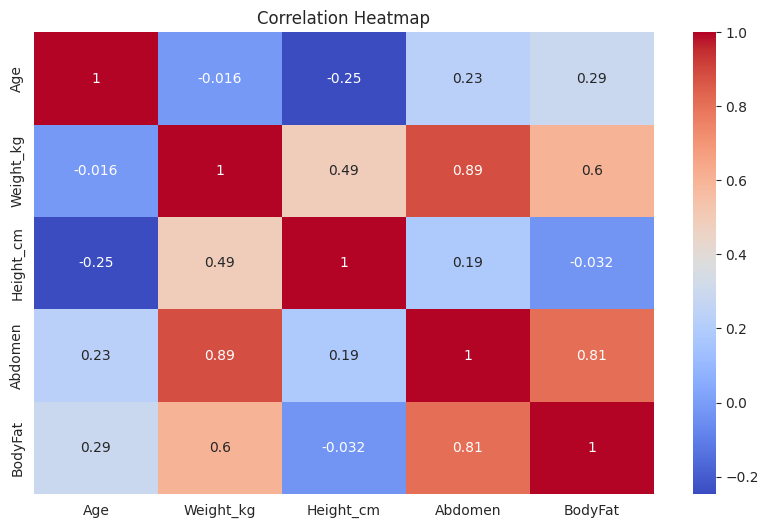

In [51]:
'''Feature Selction'''
features = ['Age', 'Weight_kg', 'Height_cm', 'Abdomen']  # Abdomen = Waist
target = 'BodyFat'

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[features + [target]].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [52]:
'''Creating data for model: dependent and independent data '''
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (200, 4)
Testing set : (50, 4)


In [53]:
''' MOdel for Body Fat analysis'''
bodyfat_model = LinearRegression()
bodyfat_model.fit(X_train, y_train)

# Predictions
y_pred = bodyfat_model.predict(X_test)

# Evaluation
print("===== Body Fat Model Performance =====")
print(f"R² Score     : {r2_score(y_test, y_pred):.4f}")
print(f"MAE          : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE         : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

print("\nIntercept:", bodyfat_model.intercept_)
print("Coefficients:")
for col, coef in zip(features, bodyfat_model.coef_):
    print(f"  {col}: {coef:.4f}")

===== Body Fat Model Performance =====
R² Score     : 0.5999
MAE          : 3.7418
RMSE         : 4.8415

Intercept: -38.576768924736314
Coefficients:
  Age: 0.0074
  Weight_kg: -0.2520
  Height_cm: -0.0553
  Abdomen: 0.9486


In [54]:
'''Creating targets on basis of the inputs by the users'''

def calculate_bmr(weight_kg, height_cm, age, gender='male'):
    return 10 * weight_kg + 6.25 * height_cm - 5 * age + 5

# Assuming mostly male dataset
df['BMR'] = df.apply(lambda row: calculate_bmr(row['Weight_kg'], row['Height_cm'], row['Age']), axis=1)

# Estimated TDEE (assuming lightly active → multiply by 1.375)
df['Calorie_Need'] = df['BMR'] * 1.375

# Protein need (simple rule: 1.6g to 2.2g per kg depending on body fat)
df['Protein_Need'] = df.apply(
    lambda row: row['Weight_kg'] * (2.0 if row['BodyFat'] < 20 else 1.6), axis=1
)

print(df[['BodyFat', 'BMR', 'Calorie_Need', 'Protein_Need']].head())

   BodyFat         BMR  Calorie_Need  Protein_Need
0     12.3  1665.19691   2289.645751    139.933132
1      6.1  1827.81689   2513.248224    157.169628
2     25.3  1645.25043   2262.219341    111.765069
3     10.4  1859.97997   2557.472459    167.602244
4     28.7  1851.83701   2546.275889    133.718922


In [55]:
'''Model 2 : for calories and diet prediction'''
X_cal = df[features]
y_cal = df['Calorie_Need']

X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=42
)

calorie_model = LinearRegression()
calorie_model.fit(X_train_cal, y_train_cal)

y_pred_cal = calorie_model.predict(X_test_cal)

print("===== Calorie Need Model Performance =====")
print(f"R² Score : {r2_score(y_test_cal, y_pred_cal):.4f}")
print(f"MAE      : {mean_absolute_error(y_test_cal, y_pred_cal):.2f} kcal")

===== Calorie Need Model Performance =====
R² Score : 1.0000
MAE      : 0.00 kcal


In [56]:
'''MOdel 3: For protien inneed '''
X_pro = df[features]
y_pro = df['Protein_Need']

X_train_pro, X_test_pro, y_train_pro, y_test_pro = train_test_split(
    X_pro, y_pro, test_size=0.2, random_state=42
)

protein_model = LinearRegression()
protein_model.fit(X_train_pro, y_train_pro)

y_pred_pro = protein_model.predict(X_test_pro)

print("===== Protein Need Model Performance =====")
print(f"R² Score : {r2_score(y_test_pro, y_pred_pro):.4f}")
print(f"MAE      : {mean_absolute_error(y_test_pro, y_pred_pro):.2f} grams")

===== Protein Need Model Performance =====
R² Score : 0.7757
MAE      : 10.37 grams


In [57]:
'''Saving models '''
joblib.dump(bodyfat_model, "bodyfat_model.pkl")
joblib.dump(calorie_model, "calorie_model.pkl")
joblib.dump(protein_model, "protein_model.pkl")

print("All models saved successfully!")

All models saved successfully!


In [58]:
'''prediction function '''
def predict_health(age, weight_kg, height_cm, abdomen_cm):
    input_data = np.array([[age, weight_kg, height_cm, abdomen_cm]])

    bodyfat = bodyfat_model.predict(input_data)[0]
    calories = calorie_model.predict(input_data)[0]
    protein = protein_model.predict(input_data)[0]

    bmi = weight_kg / ((height_cm/100) ** 2)

    return {
        "BodyFat_%": round(bodyfat, 2),
        "BMI": round(bmi, 2),
        "Daily_Calories": round(calories, 0),
        "Daily_Protein_g": round(protein, 1)
    }

# Test
print(predict_health(age=28, weight_kg=78, height_cm=175, abdomen_cm=88))

{'BodyFat_%': np.float64(15.78), 'BMI': 25.47, 'Daily_Calories': np.float64(2391.0), 'Daily_Protein_g': np.float64(145.4)}


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [59]:
'''Saving features'''
from google.colab import files

files.download("bodyfat_model.pkl")
files.download("calorie_model.pkl")
files.download("protein_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>